
**Problem Statement:**

The Titanic disaster is one of the most well-known maritime tragedies in history. During the sinking of the RMS Titanic in 1912, not all passengers survived due to various factors such as passenger class, gender, age, and other socio-economic attributes.

The objective of this project is to analyze the Titanic dataset and build predictive machine learning models to determine whether a passenger survived or not based on available features.

This study focuses on performing Exploratory Data Analysis (EDA) to understand patterns in the dataset, followed by data preprocessing to handle missing values and encode categorical variables. Two advanced gradient boosting algorithms, **XGBoost** and **LightGBM**, will be implemented to build classification models.

The performance of these models will be evaluated using metrics such as accuracy, precision, recall, and F1-score. A comparative analysis will then be conducted to determine which algorithm performs better for the Titanic survival prediction task.


In [ ]:
# Import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import warnings
warnings.filterwarnings('ignore')

In [ ]:
Train_data = pd.read_csv('Titanic_train.csv')
Test_data = pd.read_csv('Titanic_test.csv')

In [59]:
print('Train data first 5 rows:')
print(Train_data.head())
print('Test data first 5 rows:')
print(Test_data.head())

Train data first 5 rows:
   Survived  Pclass   Age  SibSp  ...     Fare  Sex_male  Embarked_Q  Embarked_S
0         0       3  22.0      1  ...   7.2500      True       False        True
1         1       1  38.0      1  ...  71.2833     False       False       False
2         1       3  26.0      0  ...   7.9250     False       False        True
3         1       1  35.0      1  ...  53.1000     False       False        True
4         0       3  35.0      0  ...   8.0500      True       False        True

[5 rows x 9 columns]
Test data first 5 rows:
   Pclass   Age  SibSp  Parch     Fare  Sex_male  Embarked_Q  Embarked_S
0       3  34.5      0      0   7.8292      True        True       False
1       3  47.0      1      0   7.0000     False       False        True
2       2  62.0      0      0   9.6875      True        True       False
3       3  27.0      0      0   8.6625      True       False        True
4       3  22.0      1      1  12.2875     False       False        True


In [ ]:
print('Train_data shape:',Train_data.shape)
print('Test_data shape:',Test_data.shape)

Train_data shape: (891, 12)
Test_data shape: (418, 11)


In [69]:
print('\nTrain Data Info:')
print(Train_data.info())
print('\nTest Data Info:')
print(Test_data.info())



Train Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Age         891 non-null    float64
 3   SibSp       891 non-null    int64  
 4   Parch       891 non-null    int64  
 5   Fare        891 non-null    float64
 6   Sex_male    891 non-null    bool   
 7   Embarked_Q  891 non-null    bool   
 8   Embarked_S  891 non-null    bool   
dtypes: bool(3), float64(2), int64(4)
memory usage: 44.5 KB
None

Test Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Pclass      418 non-null    int64  
 1   Age         418 non-null    float64
 2   SibSp       418 non-null    int64  
 3   Parch       418 non-null    int

In [70]:
print('Summary stats of Train Data:')
print(Train_data.describe())
print('Summary stats of Test Data:')
print(Test_data.describe())


Summary stats of Train Data:
         Survived      Pclass         Age       SibSp       Parch        Fare
count  891.000000  891.000000  891.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.361582    0.523008    0.381594   32.204208
std      0.486592    0.836071   13.019697    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    2.000000   22.000000    0.000000    0.000000    7.910400
50%      0.000000    3.000000   28.000000    0.000000    0.000000   14.454200
75%      1.000000    3.000000   35.000000    1.000000    0.000000   31.000000
max      1.000000    3.000000   80.000000    8.000000    6.000000  512.329200
Summary stats of Test Data:
           Pclass         Age       SibSp       Parch        Fare
count  418.000000  418.000000  418.000000  418.000000  418.000000
mean     2.265550   29.805024    0.447368    0.392344   35.576535
std      0.841838   12.667969    0.896760  

**Explortory Data Analysis**


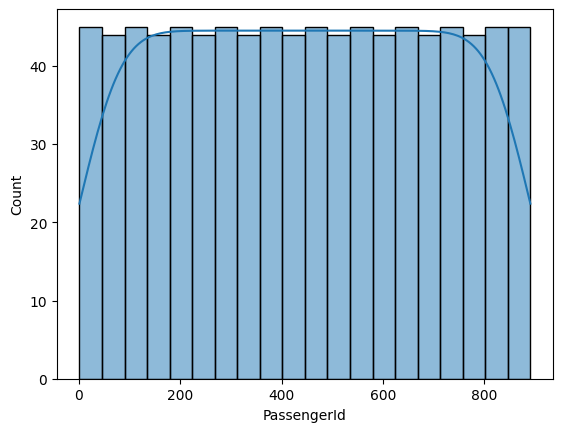

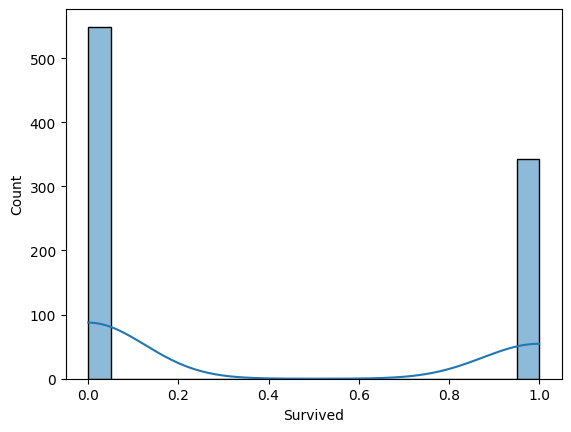

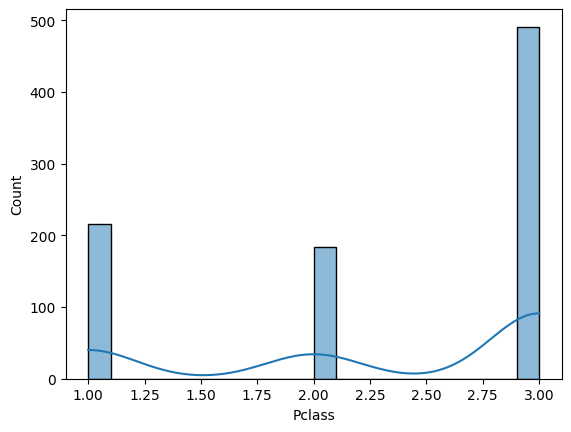

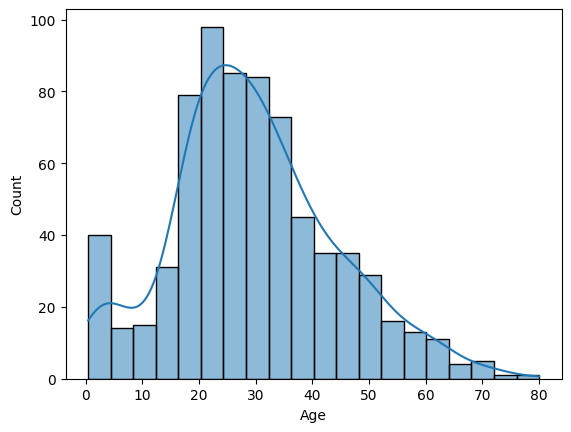

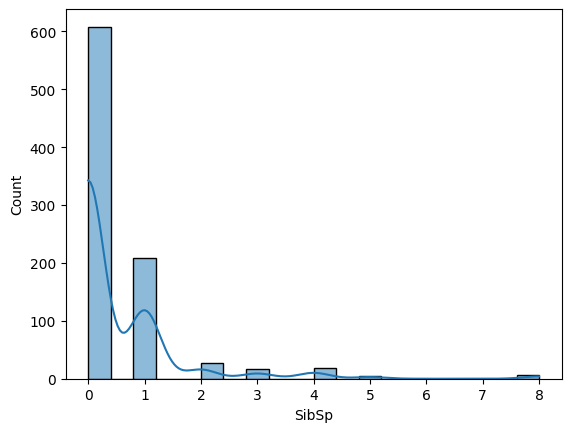

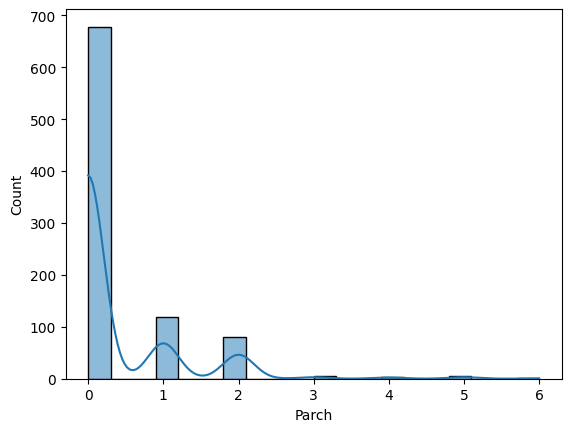

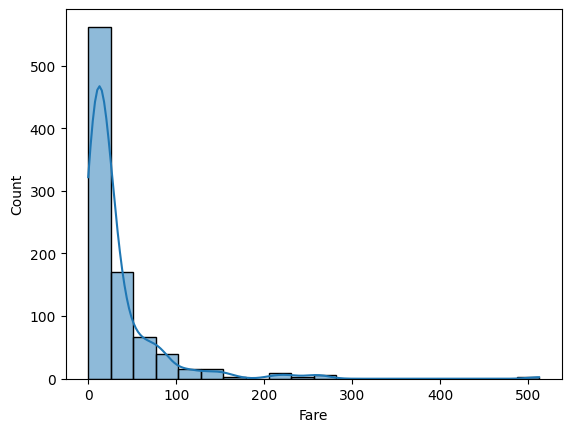

In [ ]:
#EDA
# Visualization
for col in Train_data.select_dtypes(include=['number']).columns:
    plt.figure()
    sns.histplot(Train_data[col],bins = 20, kde=True)

The histograms reveal the distribution of numerical features in the Titanic dataset. The majority of passengers belong to the third class, and most travelers were between 20 and 40 years old. The Fare variable shows a right-skewed distribution, indicating that most passengers paid lower fares. Additionally, the dataset is slightly imbalanced, with more passengers not surviving than surviving.

<Axes: xlabel='Sex', ylabel='Survived'>

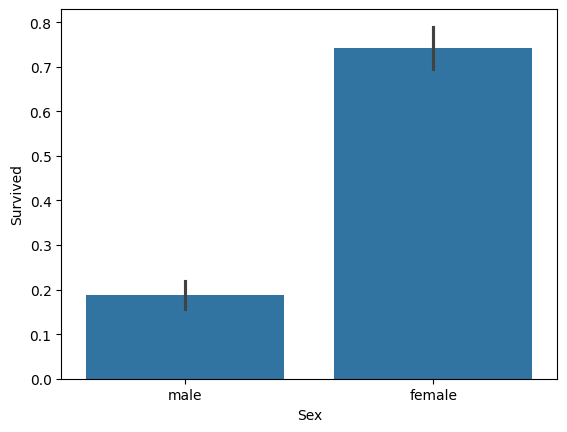

In [ ]:
# Barplot for Sex and Survived columns (To check which gender survived the most)
sns.barplot(data = Train_data, x = 'Sex',y = 'Survived')

<Axes: xlabel='Pclass', ylabel='Survived'>

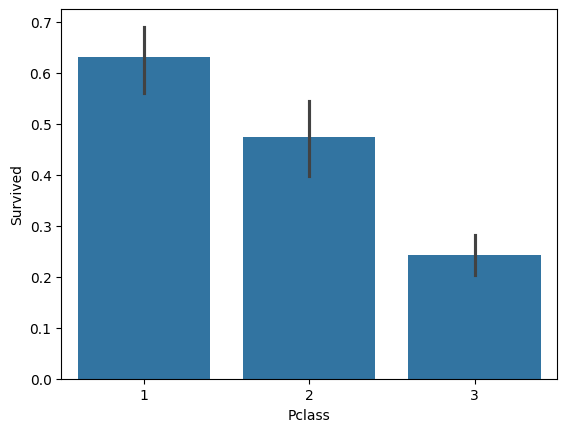

In [ ]:
# Barplot for the Pclass and Survived
sns.barplot(data = Train_data, x = 'Pclass', y= 'Survived')


The plot shows that survival rates varied significantly by passenger class. First-class passengers had the highest survival rate, followed by second-class passengers, while third-class passengers had the lowest survival rate. This suggests that socio-economic status played an important role in survival during the Titanic disaster.


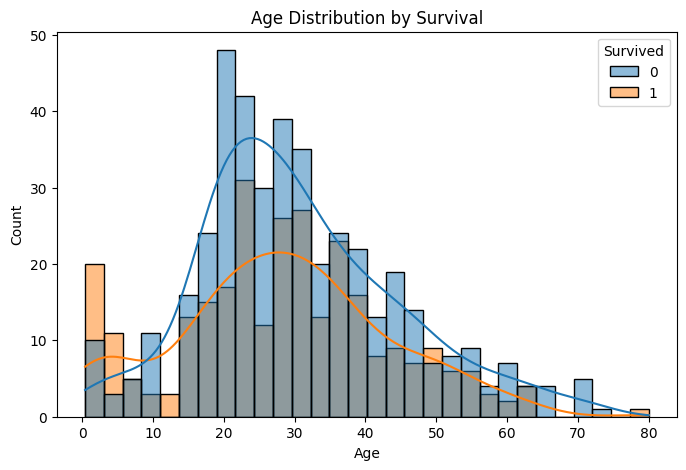

In [ ]:
# barplot for Age vs Survived
plt.figure(figsize=(8,5))
sns.histplot(data=Train_data, x="Age", hue="Survived", kde=True, bins=30)
plt.title("Age Distribution by Survival")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

The age distribution shows that most passengers were between 20–40 years old. Children under 10 had relatively higher survival rates, likely due to evacuation priorities. Older passengers had lower survival chances, indicating that age had some influence on survival but was not the strongest factor.

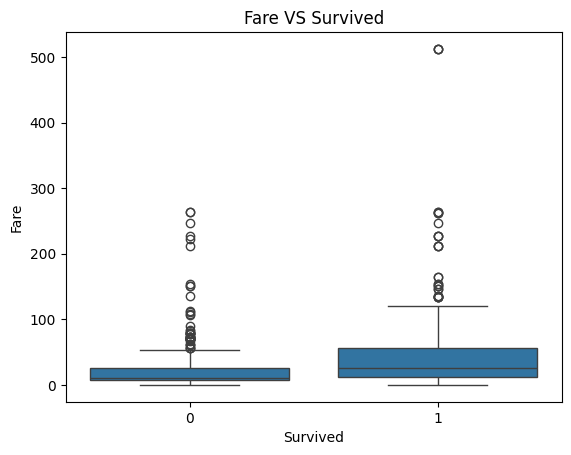

In [ ]:
# Boxplot of Fare vs Survived
sns.boxplot(data = Train_data,x = 'Survived', y = 'Fare')
plt.title('Fare VS Survived')
plt.show()

The box plot shows that passengers who survived generally paid higher fares compared to those who did not survive. This suggests that passengers with higher ticket fares, often associated with higher passenger classes, had better chances of survival during the Titanic disaster.

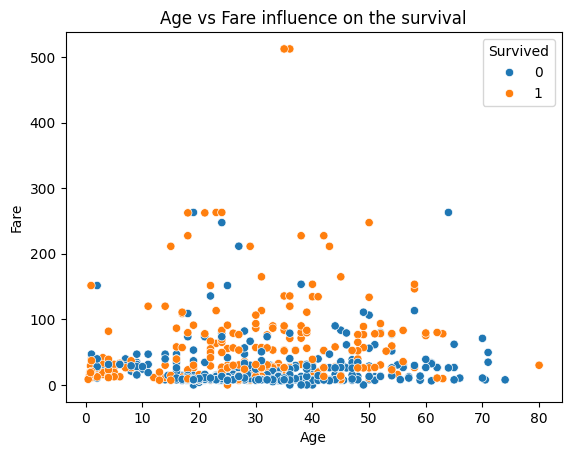

In [ ]:
# Scatter plot of Age vs Fare
sns.scatterplot(data = Train_data, x = 'Age', y = 'Fare',hue = 'Survived')
plt.title('Age vs Fare influence on the survival')
plt.show()

The scatter plot shows the relationship between age and fare with respect to survival. Passengers who paid higher fares appear to have higher survival rates compared to those who paid lower fares. In contrast, age does not show a strong visible pattern with survival, suggesting that fare (which is related to passenger class) had a stronger influence on survival outcomes than age.


**Data Preprocessing**

In [76]:
print('\nNull Values In Train Data:\n')
print(Train_data.isnull().sum())
print('\nNull Values In Test Data:\n')
print(Test_data.isnull().sum())


Null Values In Train Data:

Survived      0
Pclass        0
Age           0
SibSp         0
Parch         0
Fare          0
Sex_male      0
Embarked_Q    0
Embarked_S    0
dtype: int64

Null Values In Test Data:

Pclass        0
Age           0
SibSp         0
Parch         0
Fare          0
Sex_male      0
Embarked_Q    0
Embarked_S    0
dtype: int64


In [ ]:
# Drop Cabin
Train_data.drop("Cabin", axis=1,errors = 'ignore', inplace=True)
Test_data.drop("Cabin", axis=1,errors = 'ignore', inplace=True)

# Age imputation
median_age = Train_data["Age"].median()
Train_data["Age"] = Train_data["Age"].fillna(median_age)
Test_data["Age"] = Test_data["Age"].fillna(median_age)

# Embarked imputation
mode_embarked = Train_data["Embarked"].mode()[0]
Train_data["Embarked"] = Train_data["Embarked"].fillna(mode_embarked)

# Fare imputation (test dataset)
median_fare = Train_data["Fare"].median()
Test_data["Fare"] = Test_data["Fare"].fillna(median_fare)


In [82]:
print('\nNull Values In Train Data After Filling Missing Values:\n')
print(Train_data.isnull().sum())
print('\nNull Values In Test Data After Filling Missing Values:\n')
print(Test_data.isnull().sum())



Null Values In Train Data After Filling Missing Values:

Survived      0
Pclass        0
Age           0
SibSp         0
Parch         0
Fare          0
Sex_male      0
Embarked_Q    0
Embarked_S    0
dtype: int64

Null Values In Test Data After Filling Missing Values:

Pclass        0
Age           0
SibSp         0
Parch         0
Fare          0
Sex_male      0
Embarked_Q    0
Embarked_S    0
dtype: int64


In [ ]:
# Categorical cols
cat_cols= Train_data.select_dtypes(include = ['object']).columns
cat_cols


Index(['Name', 'Sex', 'Ticket', 'Embarked'], dtype='object')

In [ ]:
# Dropping unnecessary columns
Train_data.drop(['PassengerId','Name','Ticket'],axis = 1,inplace = True)
Test_data.drop(['PassengerId','Name','Ticket'],axis = 1,inplace = True)



In [ ]:
# Encode Categorical Variables
Train_data = pd.get_dummies(Train_data, columns=["Sex","Embarked"], drop_first=True)
Test_data = pd.get_dummies(Test_data, columns=["Sex","Embarked"], drop_first=True)
Train_data.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


In [ ]:
# Defining target and the features
X = Train_data.drop('Survived',axis = 1)
Y = Train_data['Survived']

In [ ]:
# Train test split(Splitting the train data cause we do not have target variable in the test data)
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,
                                                 test_size = 0.2,
                                                 stratify = Y,
                                                 random_state = 42
                                                 )


In [ ]:
# Train the XGBOOST model
from xgboost import XGBClassifier
xg_model = XGBClassifier(n_estimators = 100,
                         max_depth = 3,
                         learning_rate = 0.1,
                         random_state = 42)

xg_model.fit(X_train,Y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
# Train the LGBM model
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42
)

lgbm_model.fit(X_train, Y_train)


[LightGBM] [Info] Number of positive: 273, number of negative: 439
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000303 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 206
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.383427 -> initscore=-0.475028
[LightGBM] [Info] Start training from score -0.475028
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


LGBMClassifier(max_depth=3, random_state=42)

In [ ]:
# Model predictions
xg_preds = xg_model.predict(X_test)
lgbm_preds = lgbm_model.predict(X_test)


In [84]:
# Model Evaluation
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
# Performance of the xgboost model
print('XGBOOST model performance:\n')
print(f'Accuracy score:{accuracy_score(Y_test,xg_preds):.4f}')
print(f'Precision:{precision_score(Y_test,xg_preds):.4f}')
print(f'Recall:{recall_score(Y_test,xg_preds):.4f}')
print(f'F1 score:{f1_score(Y_test,xg_preds):.4f}')

# LGBM model performance
print('\nLGBM model performance:')
print(f'Accuracy score:{accuracy_score(Y_test,lgbm_preds):.4f}')
print(f'Precision:{precision_score(Y_test,lgbm_preds):.4f}')
print(f'Recall:{recall_score(Y_test,lgbm_preds):.4f}')
print(f'F1 score:{f1_score(Y_test,lgbm_preds):.4f}')



XGBOOST model performance:

Accuracy score:0.7933
Precision:0.7963
Recall:0.6232
F1 score:0.6992

LGBM model performance:
Accuracy score:0.7821
Precision:0.7679
Recall:0.6232
F1 score:0.6880


# **Comparison of both models**
| Model    | Accuracy | Precision | Recall | F1     |
| -------- | -------- | --------- | ------ | ------ |
| XGBoost  | 0.7933   | 0.7963    | 0.6232 | 0.6992 |
| LightGBM | 0.7821   | 0.7679    | 0.6232 | 0.6880 |

Both XGBoost and LightGBM models were trained to predict passenger survival on the Titanic dataset. The results show that the XGBoost model performed slightly better than the LightGBM model across most evaluation metrics. XGBoost achieved an accuracy of 0.7933, while LightGBM achieved 0.7821. XGBoost also showed higher precision and F1-score, indicating better overall classification performance. However, both models produced the same recall value (0.6232), suggesting similar ability in identifying actual survivors. Overall, XGBoost demonstrated marginally better predictive performance for this dataset.
# Conclusion:Overall, both gradient boosting models performed well, but XGBoost showed a slight performance advantage over LightGBM on the Titanic survival prediction task.

# **Cross Validation**

In [ ]:
# Cross validation on xgboost model
from sklearn.model_selection import cross_val_score
xg_cross_val = cross_val_score(xg_model, X, Y, cv = 5, scoring='accuracy')
print(f"XGBOOST CROSS VALIDATION SCORE:{xg_cross_val.mean():.2f}")

XGBOOST CROSS VALIDATION SCORE:0.82


In [ ]:
# Cross validation on lightgbm model
lgbm_cross_val = cross_val_score(lgbm_model, X, Y, cv=5, scoring='accuracy')

print(f"LightGBM Cross-Validation Accuracy: {lgbm_cross_val.mean():.2f}")

[LightGBM] [Info] Number of positive: 273, number of negative: 439
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000125 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 203
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.383427 -> initscore=-0.475028
[LightGBM] [Info] Start training from score -0.475028
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


Cross-validation was performed to evaluate model performance across multiple data splits. Both XGBoost and LightGBM achieved an average accuracy of 0.82, indicating stable and consistent performance.

# **Hyperparameter Tuning**

In [30]:
# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100,200],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.001,0.1,0.2]
}

grid_search = GridSearchCV(XGBClassifier(random_state = 42),

                           param_grid,
                           cv = 5,
                           scoring = 'accuracy')
grid_search.fit(X_train,Y_train)

print(f'Best parameters of XGBOOST model:{grid_search.best_params_}')

# Tuning lightgbm model
param_grid_lgbm = {
    'n_estimators':[100,200],
    'max_depth':[3,4,5],
    'learning_rate':[0.05,0.1]
}

grid_lgbm = GridSearchCV(
    LGBMClassifier(random_state=42, verbose=-1),
    param_grid_lgbm,
    cv=5,
    scoring='accuracy'
)

grid_lgbm.fit(X_train, Y_train)

print("Best LGBM params:", grid_lgbm.best_params_)

Best parameters of XGBOOST model:{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
Best LGBM params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}


In [35]:
# Retraining the model with tuned(best parameters)
# XGBOOST model
best_xgb = XGBClassifier(
    learning_rate=0.1,
    max_depth=3,
    n_estimators=200,
    random_state=42
)

best_xgb.fit(X_train, Y_train)

# Lightgbm model
best_lgbm = LGBMClassifier(
    learning_rate=0.1,
    max_depth=3,
    n_estimators=100,
    random_state = 42)
best_lgbm.fit(X_train,Y_train)


LGBMClassifier(max_depth=3, random_state=42)

In [37]:
best_preds_xg = best_xgb.predict(X_test)
best_preds_lgbm = best_lgbm.predict(X_test)

In [85]:
# Model Evaluation After tuning

# Performance of the xgboost model
print('XGBOOST model performance after tuning:\n')
print(f'Accuracy score:{accuracy_score(Y_test,best_preds_xg)*100:.2f}%')
print(f'Precision:{precision_score(Y_test,best_preds_xg)*100:.2f}%')
print(f'Recall:{recall_score(Y_test,best_preds_xg)*100:.2f}%')
print(f'F1 score:{f1_score(Y_test,best_preds_xg)*100:.2f}%')

# LGBM model performance
print('\nLGBM model performance after tuning:')
print(f'Accuracy score:{accuracy_score(Y_test,best_preds_lgbm)*100:.2f}%')
print(f'Precision:{precision_score(Y_test,best_preds_lgbm)*100:.2f}%')
print(f'Recall:{recall_score(Y_test,best_preds_lgbm)*100:.2f}%')
print(f'F1 score:{f1_score(Y_test,best_preds_lgbm)*100:.2f}%')

XGBOOST model performance after tuning:

Accuracy score:79.89%
Precision:77.97%
Recall:66.67%
F1 score:71.88%

LGBM model performance after tuning:
Accuracy score:78.21%
Precision:76.79%
Recall:62.32%
F1 score:68.80%


The performance of the tuned models is similar to the base models, indicating that the default parameters were already effective for this dataset. This is expected due to the small size and relatively simple structure of the Titanic dataset. Hyperparameter tuning resulted in only marginal improvements, suggesting that the models were already near optimal performance.

# Feature Importance

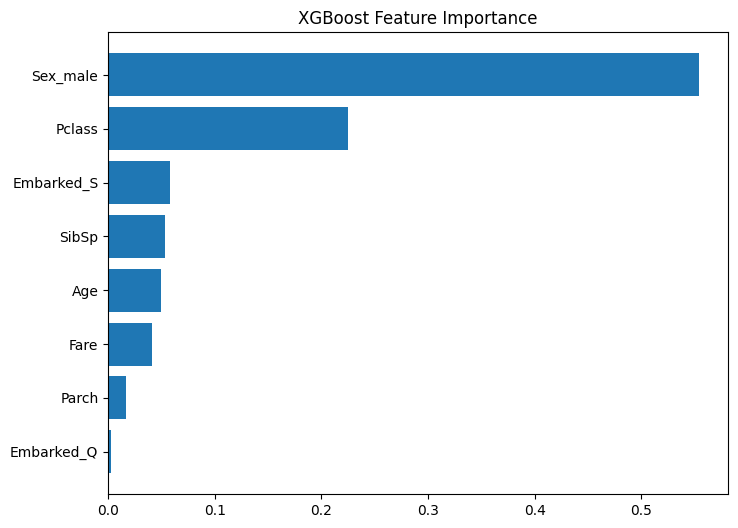

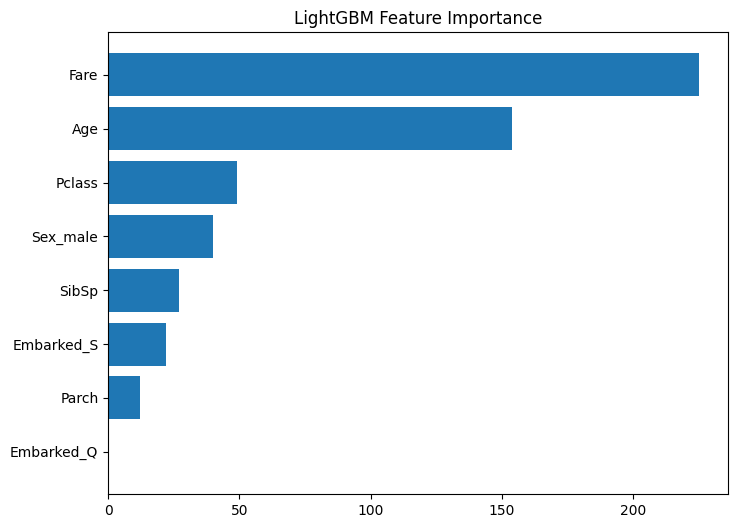

In [39]:
# Feature Importance of the tuned model as tuned model is best model till now.
xgb_importance = best_xgb.feature_importances_

xgb_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_importance
}).sort_values(by="Importance", ascending=False)

# Plot
plt.figure(figsize=(8,6))
plt.barh(xgb_df["Feature"], xgb_df["Importance"])
plt.gca().invert_yaxis()
plt.title("XGBoost Feature Importance")
plt.show()

lgb_importance = best_lgbm.feature_importances_

lgb_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": lgb_importance
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8,6))
plt.barh(lgb_df["Feature"], lgb_df["Importance"])
plt.gca().invert_yaxis()
plt.title("LightGBM Feature Importance")
plt.show()




# Comparison of tuned models Visualization(matplotlib)

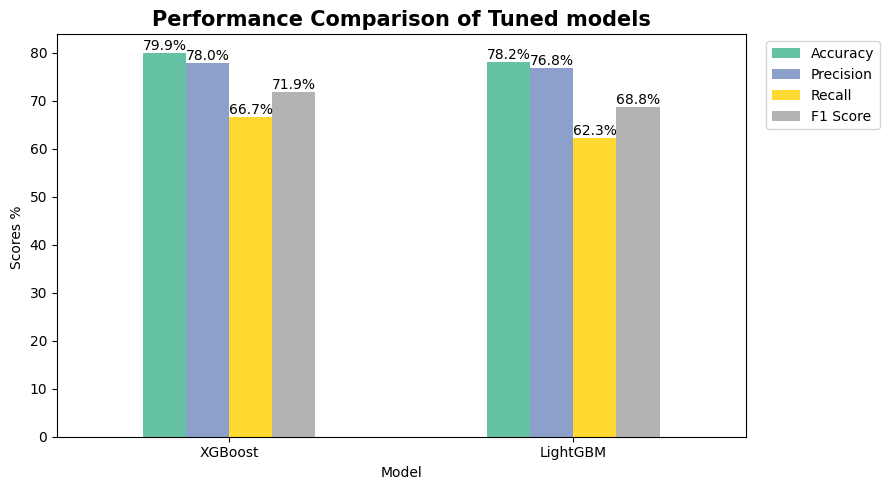

In [57]:
# Tuned model results
results = pd.DataFrame({
    "Model": ["XGBoost", "LightGBM"],
    "Accuracy": [79.89, 78.21],
    "Precision": [77.97, 76.79],
    "Recall": [66.67, 62.32],
    "F1 Score": [71.88, 68.80]
})

results.set_index('Model',inplace = True)

# plot the results bar chart
results.plot(kind = 'bar',figsize = (9,5),colormap= 'Set2' )
plt.title("Performance Comparison of Tuned models",fontsize = 15,fontweight = 'bold')
plt.ylabel("Scores % ")
plt.xticks(rotation = 0)
plt.legend(bbox_to_anchor=(1.02, 1))
plt.tight_layout()
for bars in plt.gca().containers:
  plt.bar_label(bars,fmt='%.1f%%')
plt.show()


# **Comparative Analysis**

The performance of the tuned XGBoost and LightGBM models was evaluated using accuracy, precision, recall, and F1-score.
| Model    | Accuracy | Precision | Recall | F1 Score |
| -------- | -------- | --------- | ------ | -------- |
| XGBoost  | 79.89%   | 77.97%    | 66.67% | 71.88%   |
| LightGBM | 78.21%   | 76.79%    | 62.32% | 68.80%   |

The results indicate that XGBoost slightly outperforms LightGBM across all evaluation metrics.

Accuracy: XGBoost achieved higher accuracy (79.89%) compared to LightGBM (78.21%), indicating better overall prediction performance.

Precision: XGBoost has slightly higher precision, meaning it is better at correctly identifying passengers who survived.

Recall: XGBoost shows a noticeable improvement in recall, suggesting it is more effective at identifying actual survivors.

F1 Score: The higher F1-score of XGBoost indicates a better balance between precision and recall.

# **Final Conclusion:**

Both models performed well and demonstrated strong predictive capabilities. However, XGBoost provided slightly better performance, making it the preferred model for this classification task.The consistent cross-validation results (~82%) and similar test performance indicate that both models generalize well without overfitting.